In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# AI & ML Internship - Task 4: Classification with Logistic Regression

## Objective

Build a binary classification model using Logistic Regression.

## Dataset

Breast Cancer Wisconsin Dataset from scikit-learn.

## Tools

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

## Tasks

1. Load and explore a binary classification dataset.
2. Split the data into training and testing sets.
3. Standardize the features.
4. Train a Logistic Regression model.
5. Evaluate the model using:
   - Confusion Matrix
   - Precision
   - Recall
   - ROC-AUC
6. Tune the classification threshold.
7. Explain the sigmoid function.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    f1_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Breast Cancer Wisconsin dataset

cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(
    cancer.target,
    name="target"
)

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Target classes

print("Target classes:")
print(cancer.target_names)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Target classes:
['malignant' 'benign']

Target distribution:
target
0    212
1    357
Name: count, dtype: int64


In [5]:
# Dataset information

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nData types:")
print(X.dtypes.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())

Number of samples: 569
Number of features: 30

Data types:
float64    30
Name: count, dtype: int64

Missing values:
0


In [6]:
# Statistical summary

display(X.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


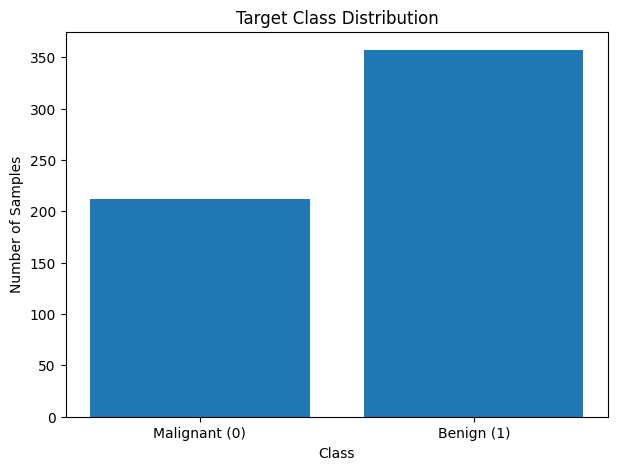

In [7]:
# Visualize class distribution

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ['Malignant (0)', 'Benign (1)'],
    class_counts.values
)

plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Target Class Distribution')

plt.show()

In [8]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (455, 30)
Testing data: (114, 30)
Training target: (455,)
Testing target: (114,)


In [9]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed!")
print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Feature standardization completed!
Training scaled shape: (455, 30)
Testing scaled shape: (114, 30)


In [10]:
# Check the standardized training data

print("Mean of first 5 standardized features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 standardized features:")
print(X_train_scaled[:, :5].std(axis=0))

Mean of first 5 standardized features:
[-4.31742554e-15  2.24606658e-15 -7.38359313e-16  1.71779562e-16
  5.22695440e-15]

Standard deviation of first 5 standardized features:
[1. 1. 1. 1. 1.]


## Logistic Regression Model

Logistic Regression is a classification algorithm that predicts the probability of an observation belonging to a particular class.

The predicted probability is converted into a class using a classification threshold.

In [11]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [12]:
# Make predictions

y_pred = logistic_model.predict(X_test_scaled)

# Predicted probabilities for the positive class
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(y_prob[:10])

Predictions generated successfully!

First 10 predicted classes:
[0 1 0 1 0 1 1 0 0 0]

First 10 predicted probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [13]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


Confusion Matrix:
[[41  1]
 [ 1 71]]


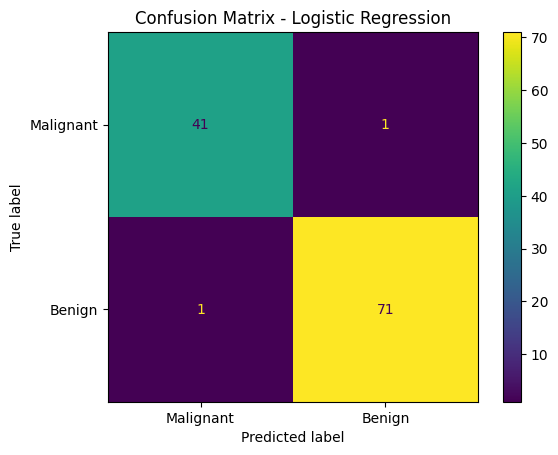

In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Malignant', 'Benign']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [15]:
# Calculate precision and recall

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9861111111111112
Recall: 0.9861111111111112


In [16]:
# Calculate ROC-AUC

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9953703703703703


In [17]:
# Complete classification report

print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Malignant', 'Benign']
    )
)

Classification Report
---------------------
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



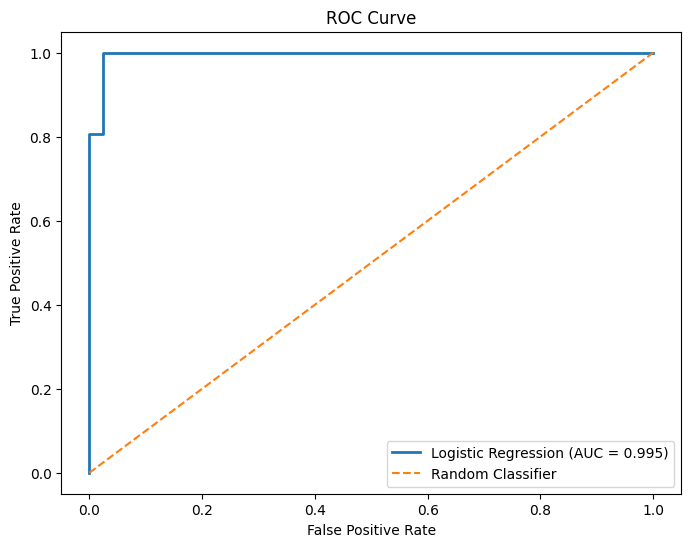

In [18]:
# Plot ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [19]:
# Threshold tuning

thresholds_to_test = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for threshold in thresholds_to_test:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    precision_value = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    recall_value = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    f1_value = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    threshold_results.append([
        threshold,
        precision_value,
        recall_value,
        f1_value
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        'Threshold',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.935065,1.000000,0.966443
1,0.15,0.947368,1.000000,0.972973
2,0.20,0.972973,1.000000,0.986301
3,0.25,0.972973,1.000000,0.986301
4,0.30,0.972973,1.000000,0.986301
5,0.35,0.972973,1.000000,0.986301
6,0.40,0.986111,0.986111,0.986111
7,0.45,0.986111,0.986111,0.986111
8,0.50,0.986111,0.986111,0.986111
9,0.55,0.985507,0.944444,0.964539


In [20]:
# Find the threshold with the highest F1 score

best_row = threshold_df.loc[
    threshold_df['F1 Score'].idxmax()
]

best_threshold = best_row['Threshold']

print("Best Threshold:", best_threshold)
print("Precision:", best_row['Precision'])
print("Recall:", best_row['Recall'])
print("F1 Score:", best_row['F1 Score'])

Best Threshold: 0.20000000000000004
Precision: 0.972972972972973
Recall: 1.0
F1 Score: 0.9863013698630136


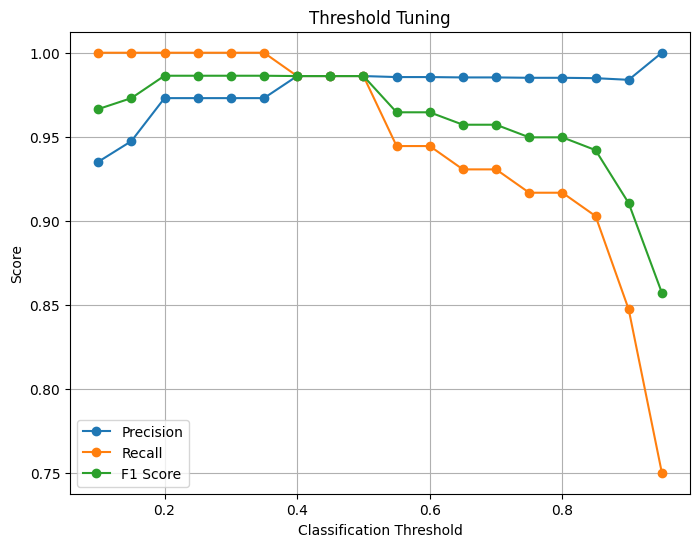

In [21]:
# Plot Precision and Recall for different thresholds

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1 Score'],
    marker='o',
    label='F1 Score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning')
plt.legend()
plt.grid(True)

plt.show()

In [22]:
# Threshold tuning

thresholds_to_test = np.arange(0.1, 1.0, 0.05)

threshold_results = []

for threshold in thresholds_to_test:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    precision_value = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    recall_value = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    f1_value = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    threshold_results.append([
        threshold,
        precision_value,
        recall_value,
        f1_value
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        'Threshold',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.935065,1.000000,0.966443
1,0.15,0.947368,1.000000,0.972973
2,0.20,0.972973,1.000000,0.986301
3,0.25,0.972973,1.000000,0.986301
4,0.30,0.972973,1.000000,0.986301
5,0.35,0.972973,1.000000,0.986301
6,0.40,0.986111,0.986111,0.986111
7,0.45,0.986111,0.986111,0.986111
8,0.50,0.986111,0.986111,0.986111
9,0.55,0.985507,0.944444,0.964539


In [23]:
# Find the threshold with the highest F1 score

best_row = threshold_df.loc[
    threshold_df['F1 Score'].idxmax()
]

best_threshold = best_row['Threshold']

print("Best Threshold:", best_threshold)
print("Precision:", best_row['Precision'])
print("Recall:", best_row['Recall'])
print("F1 Score:", best_row['F1 Score'])

Best Threshold: 0.20000000000000004
Precision: 0.972972972972973
Recall: 1.0
F1 Score: 0.9863013698630136


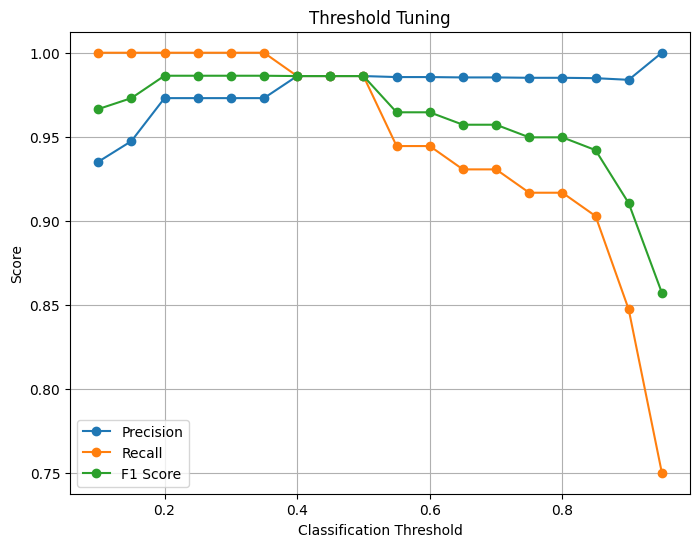

In [24]:
# Plot Precision and Recall for different thresholds

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1 Score'],
    marker='o',
    label='F1 Score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning')
plt.legend()
plt.grid(True)

plt.show()

In [25]:
# Apply the best threshold

y_pred_tuned = (
    y_prob >= best_threshold
).astype(int)

print("Results using tuned threshold")
print("--------------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_tuned)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

Results using tuned threshold
--------------------------------
Accuracy: 0.9824561403508771
Precision: 0.972972972972973
Recall: 1.0
F1 Score: 0.9863013698630136


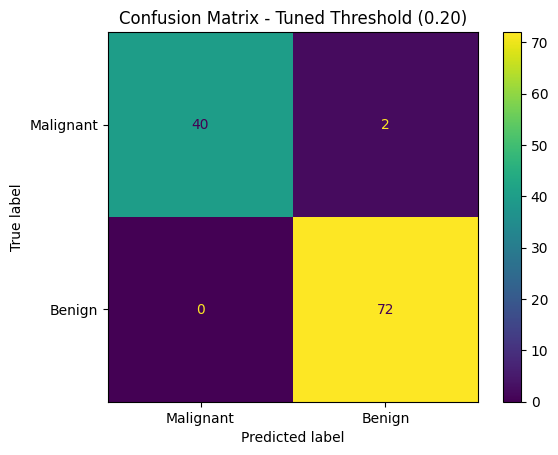

In [26]:
# Confusion Matrix using tuned threshold

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=['Malignant', 'Benign']
)

disp.plot()
plt.title(
    f"Confusion Matrix - Tuned Threshold ({best_threshold:.2f})"
)

plt.show()

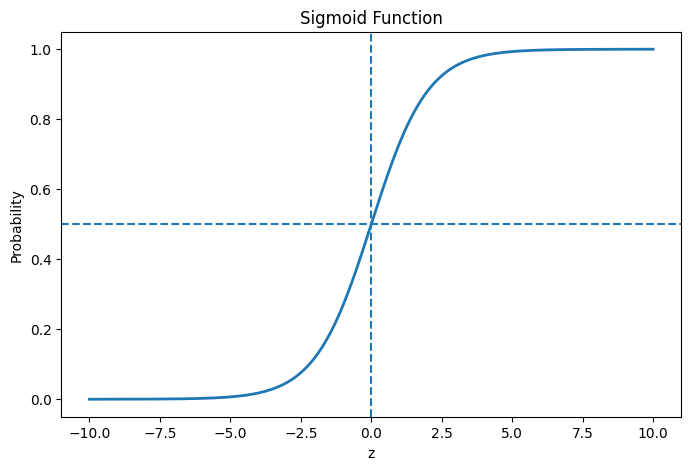

In [27]:
# Sigmoid function

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
probabilities = sigmoid(z)

plt.figure(figsize=(8, 5))

plt.plot(z, probabilities, linewidth=2)

plt.axhline(
    0.5,
    linestyle='--'
)

plt.axvline(
    0,
    linestyle='--'
)

plt.xlabel('z')
plt.ylabel('Probability')
plt.title('Sigmoid Function')

plt.show()

## Sigmoid Function Explanation

Logistic Regression uses the sigmoid function to convert the model's output into a probability between 0 and 1.

The sigmoid function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where:

- `z` is the linear combination of input features.
- The sigmoid function converts `z` into a probability.
- The output is always between 0 and 1.

For binary classification, a threshold is used to convert the probability into a class.

Using the default threshold:

- Probability >= 0.5 → Class 1
- Probability < 0.5 → Class 0

Changing the threshold changes the balance between precision and recall.

In [28]:
# Logistic Regression coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
})

coefficients['Absolute Coefficient'] = (
    coefficients['Coefficient'].abs()
)

coefficients = coefficients.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute Coefficient
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


In [29]:
# Final model evaluation summary

final_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'ROC-AUC',
        'F1 Score'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        roc_auc,
        f1_score(y_test, y_pred)
    ]
})

display(final_results)

,Metric,Score
0,Accuracy,0.982456
1,Precision,0.986111
2,Recall,0.986111
3,ROC-AUC,0.995370
4,F1 Score,0.986111


## Key Observations

- Logistic Regression was successfully used for binary classification.
- The Breast Cancer Wisconsin dataset contains two target classes: malignant and benign.
- The features were standardized before training the Logistic Regression model.
- The model was evaluated using accuracy, precision, recall, confusion matrix and ROC-AUC.
- The ROC curve was used to visualize the classification performance across different thresholds.
- Threshold tuning was performed to study the trade-off between precision and recall.
- The sigmoid function converts the model output into a probability between 0 and 1.
- The default classification threshold is 0.5, but a different threshold can be selected depending on the desired balance between precision and recall.
- Model coefficients provide information about the influence of standardized features on classification.

# Conclusion

Logistic Regression was successfully implemented for binary classification using the Breast Cancer Wisconsin dataset.

The dataset was divided into training and testing sets, and the features were standardized before model training. The Logistic Regression model was evaluated using a confusion matrix, precision, recall, accuracy and ROC-AUC.

ROC curve visualization was used to assess the model's ability to distinguish between the two classes. Classification threshold tuning was also performed to understand how changing the threshold affects precision, recall and F1 score.

The sigmoid function was studied to understand how Logistic Regression converts the model's linear output into a probability.

Overall, this task provided practical experience with binary classification, feature standardization, Logistic Regression, evaluation metrics, ROC analysis and threshold tuning.